<Figure size 640x480 with 0 Axes>

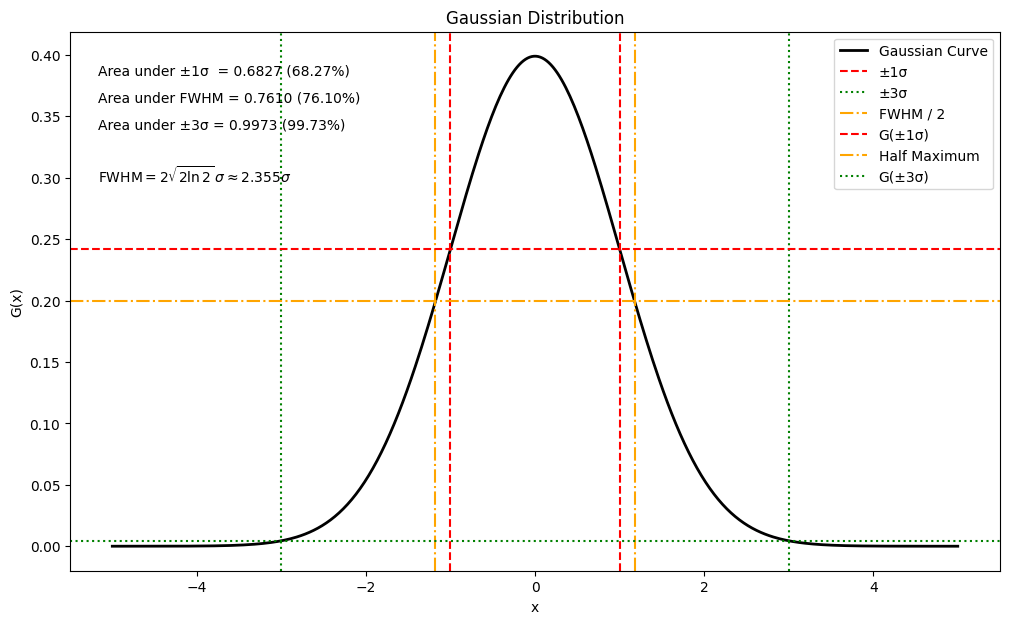

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Gaussian parameters
mu = 0.0
sigma = 1.0

x = np.linspace(-5, 5, 400)
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Key values
peak = 1 / (sigma * np.sqrt(2 * np.pi))
fwhm_half = sigma * np.sqrt(2 * np.log(2))

# Horizontal levels
level_1sigma = peak * np.exp(-0.5)
level_3sigma = peak * np.exp(-4.5)
level_fwhm = 0.5 * peak

# Areas
area_1sigma = erf(1 / np.sqrt(2))
area_3sigma = erf(3 / np.sqrt(2))
area_fwhm = erf(np.sqrt(np.log(2)))

# Plot
plt.figure()
plt.figure(figsize=(12, 7))
plt.plot(x, gaussian, color="black", linewidth=2, label="Gaussian Curve")

# Vertical markers
plt.axvline(-sigma, linestyle="--", color="red", label="±1σ")
plt.axvline(sigma, linestyle="--", color="red")

plt.axvline(-3*sigma, linestyle=":", color="green", label="±3σ")
plt.axvline(3*sigma, linestyle=":", color="green")

plt.axvline(-fwhm_half, linestyle="-.", color="orange", label="FWHM / 2")
plt.axvline(fwhm_half, linestyle="-.", color="orange")

# Horizontal markers
plt.axhline(level_1sigma, linestyle="--", color="red", label="G(±1σ)")
plt.axhline(level_fwhm, linestyle="-.", color="orange", label="Half Maximum")
plt.axhline(level_3sigma, linestyle=":", color="green", label="G(±3σ)")

# Annotations
plt.text(0.03, 0.92, f"Area under ±1σ  = {area_1sigma:.4f} (68.27%)", transform=plt.gca().transAxes)
plt.text(0.03, 0.87, f"Area under FWHM = {area_fwhm:.4f} (76.10%)", transform=plt.gca().transAxes)
plt.text(0.03, 0.82, f"Area under ±3σ = {area_3sigma:.4f} (99.73%)", transform=plt.gca().transAxes)
plt.text(0.03, 0.72, r"$\mathrm{FWHM}=2\sqrt{2\ln2}\,\sigma\approx2.355\sigma$",
         transform=plt.gca().transAxes)

plt.xlabel("x")
plt.ylabel("G(x)")
plt.title("Gaussian Distribution")
plt.legend()
plt.show()


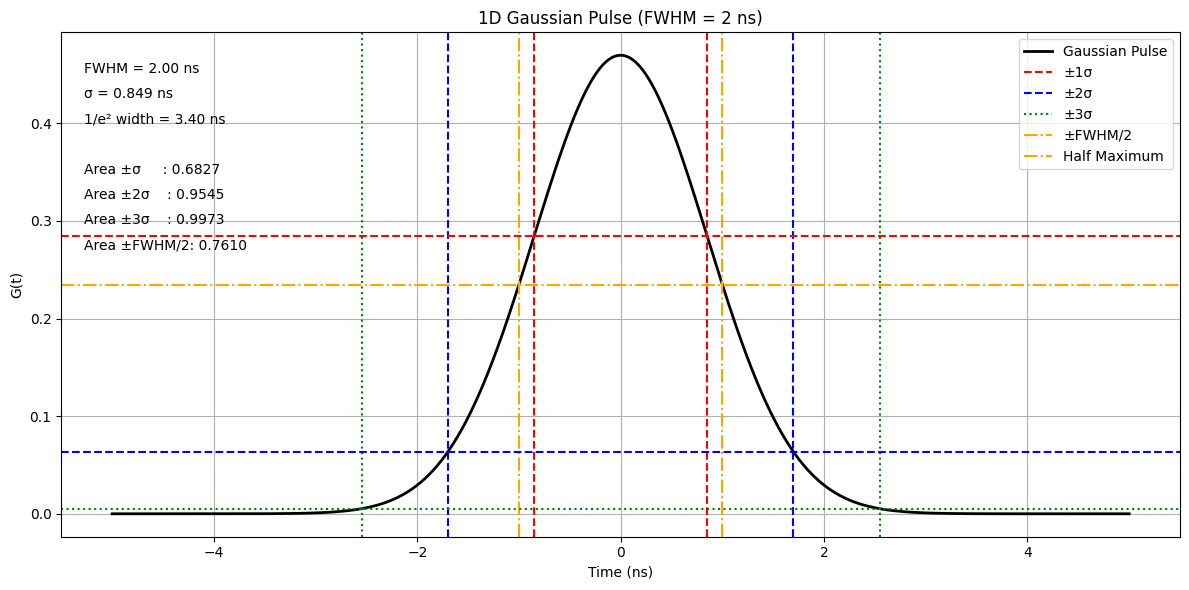

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Given pulse width
fwhm_ns = 2.0  # ns

# Gaussian conversions
sigma = fwhm_ns / (2 * np.sqrt(2 * np.log(2)))
hwhm = fwhm_ns / 2
width_1e2 = 4 * sigma

# Time axis
t = np.linspace(-5, 5, 2000)  # ns

# Gaussian pulse (normalized area = 1)
G = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-t**2 / (2 * sigma**2))
peak = G.max()

# Levels
lvl_1 = peak * np.exp(-0.5)
lvl_2 = peak * np.exp(-2.0)
lvl_3 = peak * np.exp(-4.5)
lvl_half = 0.5 * peak

# Areas
area_1 = erf(1 / np.sqrt(2))
area_2 = erf(2 / np.sqrt(2))
area_3 = erf(3 / np.sqrt(2))
area_fwhm = erf(np.sqrt(np.log(2)))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, G, color="black", lw=2, label="Gaussian Pulse")

# Vertical markers
for x, ls, c, lbl in [
    ( sigma, "--", "red", "±1σ"),
    (-sigma, "--", "red", None),
    ( 2*sigma, "--", "blue", "±2σ"),
    (-2*sigma, "--", "blue", None),
    ( 3*sigma, ":", "green", "±3σ"),
    (-3*sigma, ":", "green", None),
    ( hwhm, "-.", "orange", "±FWHM/2"),
    (-hwhm, "-.", "orange", None),
]:
    plt.axvline(x, linestyle=ls, color=c, label=lbl)

# Horizontal markers
plt.axhline(lvl_1, linestyle="--", color="red")
plt.axhline(lvl_2, linestyle="--", color="blue")
plt.axhline(lvl_3, linestyle=":", color="green")
plt.axhline(lvl_half, linestyle="-.", color="orange", label="Half Maximum")

# Text
plt.text(0.02, 0.92, f"FWHM = {fwhm_ns:.2f} ns", transform=plt.gca().transAxes)
plt.text(0.02, 0.87, f"σ = {sigma:.3f} ns", transform=plt.gca().transAxes)
plt.text(0.02, 0.82, f"1/e² width = {width_1e2:.2f} ns", transform=plt.gca().transAxes)

plt.text(0.02, 0.72, f"Area ±σ     : {area_1:.4f}", transform=plt.gca().transAxes)
plt.text(0.02, 0.67, f"Area ±2σ    : {area_2:.4f}", transform=plt.gca().transAxes)
plt.text(0.02, 0.62, f"Area ±3σ    : {area_3:.4f}", transform=plt.gca().transAxes)
plt.text(0.02, 0.57, f"Area ±FWHM/2: {area_fwhm:.4f}", transform=plt.gca().transAxes)

plt.xlabel("Time (ns)")
plt.ylabel("G(t)")
plt.title("1D Gaussian Pulse (FWHM = 2 ns)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [92]:
import numpy as np
import pandas as pd
from scipy.special import erf

# Gaussian pulse parameters

fwhm_ns = 2.0  # ns

# Conversions
sigma = fwhm_ns / (2 * np.sqrt(2 * np.log(2)))
hwhm = fwhm_ns / 2
width_1e2 = 4 * sigma

# Full widths
w_1sigma = 2 * sigma
w_2sigma = 4 * sigma
w_3sigma = 6 * sigma

# Areas (1D Gaussian)
area_1sigma = erf(1 / np.sqrt(2))
area_2sigma = erf(2 / np.sqrt(2))
area_3sigma = erf(3 / np.sqrt(2))
area_fwhm = erf(np.sqrt(np.log(2)))

#  DataFrame
data = {
    "Parameter": [
        "Sigma (σ)",
        "FWHM",
        "1/e² full width",
        "±1σ full width",
        "±2σ full width",
        "±3σ full width",
        "Energy within ±σ",
        "Energy within ±2σ",
        "Energy within ±3σ",
        "Energy within ±FWHM/2",
    ],
    "Value": [
        sigma,
        fwhm_ns,
        width_1e2,
        w_1sigma,
        w_2sigma,
        w_3sigma,
        area_1sigma,
        area_2sigma,
        area_3sigma,
        area_fwhm,
    ],
    "Units": [
        "ns",
        "ns",
        "ns",
        "ns",
        "ns",
        "ns",
        "-",
        "-",
        "-",
        "-",
    ],
}

df = pd.DataFrame(data)

# Table
def color_metric(val):
    if "Energy" in val:
        return "background-color: lightgreen; font-weight: bold"
    elif "full width" in val or "Sigma" in val:
        return "background-color: lightblue"
    elif "Sigma" in val:
        return "background-color: lightyellow; font-weight: bold"
    else:
        return ""

styled = (
    df.style
    .format({"Value": "{:.3f}"})
    .applymap(color_metric, subset=["Parameter"])
    .set_caption("1D Gaussian Pulse (FWHM = 2 ns)")
    .set_table_styles([{"selector": "caption", "props": [("color", "darkred"),
                                                         ("font-size", "16px"),
                                                         ("font-weight", "bold")]}])
)

# Display
styled


,Parameter,Value,Units
0,Sigma (σ),0.849,ns
1,FWHM,2.000,ns
2,1/e² full width,3.397,ns
3,±1σ full width,1.699,ns
4,±2σ full width,3.397,ns
5,±3σ full width,5.096,ns
6,Energy within ±σ,0.683,-
7,Energy within ±2σ,0.954,-
8,Energy within ±3σ,0.997,-
9,Energy within ±FWHM/2,0.761,-


In [5]:
import numpy as np

# Conversion constants for a Gaussian
FWHM_to_1e2 = np.sqrt(2 / np.log(2))      # multiply FWHM to get 1/e^2 width
e2_to_FWHM = np.sqrt(np.log(2) / 2)       # multiply 1/e^2 width to get FWHM

def fwhm_to_1e2(fwhm):
    """Convert FWHM to 1/e^2 full width (Gaussian)."""
    return fwhm * FWHM_to_1e2

def e2_to_fwhm(e2_width):
    """Convert 1/e^2 full width to FWHM (Gaussian)."""
    return e2_width * e2_to_FWHM

# Example usage
fwhm = 6.0  # arbitrary units
e2_width = fwhm_to_1e2(fwhm)
fwhm_back = e2_to_fwhm(e2_width)

print(f"FWHM = {fwhm}")
print(f"1/e^2 width = {e2_width:.4f}")
print(f"\nRecovered FWHM = {fwhm_back:.4f}")

# Print ratio explicitly
ratio = fwhm / e2_width
print(f"FWHM / (1/e^2 width) = {ratio:.6f}")


FWHM = 6.0
1/e^2 width = 10.1919

Recovered FWHM = 6.0000
FWHM / (1/e^2 width) = 0.588705


In [14]:
import numpy as np


# Given FWHM (meters)
fwhm = 6.0  

# Gaussian relationship
sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

# 3-sigma widths
three_sigma_radius = 3 * sigma      # ±3σ (one-sided)
three_sigma_width = 6 * sigma       # full width

print(f"FWHM               : {fwhm:.2f} m")
print(f"Sigma              : {sigma:.3f} m")
print(f"\n3-sigma radius   : {three_sigma_radius:.3f} m")
print(f"3-sigma full width : {three_sigma_width:.3f} m")


FWHM               : 6.00 m
Sigma              : 2.548 m

3-sigma radius   : 7.644 m
3-sigma full width : 15.288 m


In [15]:
import numpy as np

altitude_m = 474.066e3   # meters
fwhm = 6.0        # FWHM footprint

ifov_rad = fwhm / altitude_m
ifov_urad = ifov_rad * 1e6
ifov_arcsec = np.degrees(ifov_rad) * 3600

print(f"iFOV : {ifov_rad:.3e} rad")
print(f"iFOV : {ifov_urad:.2f} µrad")
print(f"iFOV : {ifov_arcsec:.2f} arcsec")


iFOV : 1.266e-05 rad
iFOV : 12.66 µrad
iFOV : 2.61 arcsec


In [41]:
import numpy as np

altitude = 474066.0  # meters

# Given
width_1e2 = 10.0  # m (full width)

# Gaussian conversions
sigma = width_1e2 / 2
width_3sigma = 3 * sigma

# IFOVs
ifov_1e2 = width_1e2 / altitude
ifov_3sigma = width_3sigma / altitude

print(f"1/e2 spot            : {width_1e2:.2f} m")
print(f"Sigma Width          : {sigma:.2f} m")
print(f"3-sigma full width   : {width_3sigma:.2f} m")

print(f"\niFOV (1/e^2, 10 m)   : {ifov_1e2:.3e} rad = {ifov_1e2*1e6:.2f} µrad")
print(f"iFOV (3σ, 15 m)      : {ifov_3sigma:.3e} rad = {ifov_3sigma*1e6:.2f} µrad")


1/e2 spot            : 10.00 m
Sigma Width          : 5.00 m
3-sigma full width   : 15.00 m

iFOV (1/e^2, 10 m)   : 2.109e-05 rad = 21.09 µrad
iFOV (3σ, 15 m)      : 3.164e-05 rad = 31.64 µrad


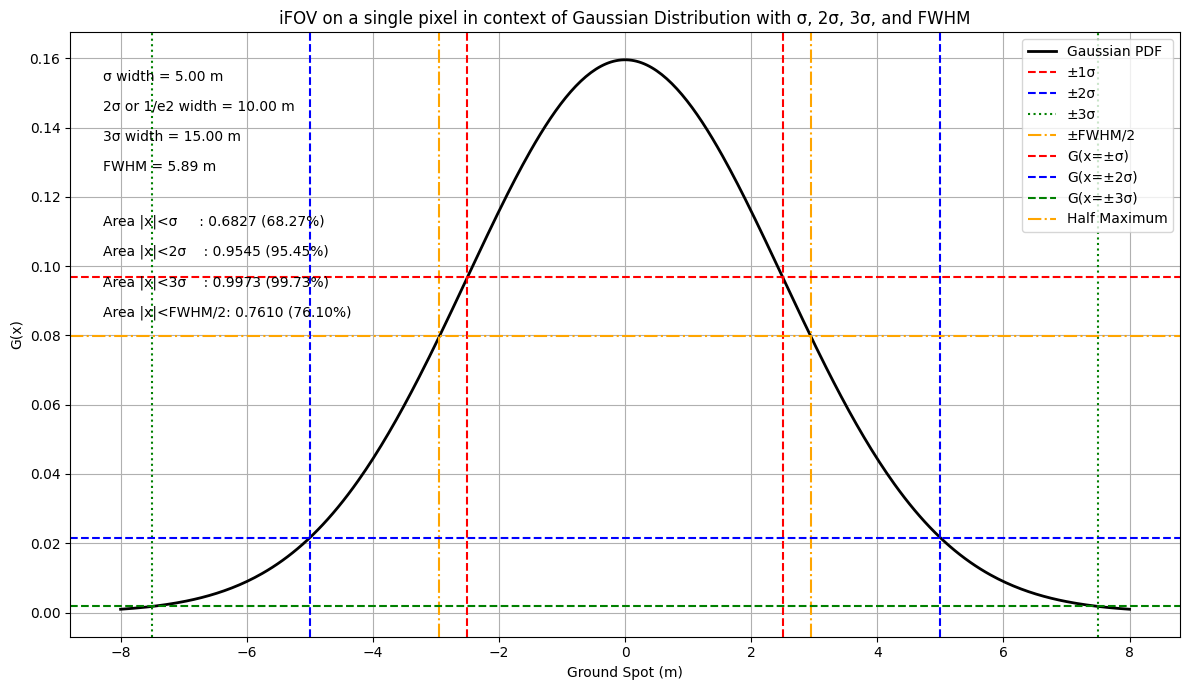

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Gaussian parameters
mu = 0.0
sigma = 2.5

x = np.linspace(-8, 8, 400)
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Peak and widths
peak = 1 / (sigma * np.sqrt(2 * np.pi))
hwhm = sigma * np.sqrt(2 * np.log(2))
fwhm = 2 * hwhm

# Levels
level_1sigma = peak * np.exp(-0.5)
level_2sigma = peak * np.exp(-2.0)
level_3sigma = peak * np.exp(-4.5)
level_fwhm = 0.5 * peak

# Areas
area_1sigma = erf(1 / np.sqrt(2))
area_2sigma = erf(2 / np.sqrt(2))
area_3sigma = erf(3 / np.sqrt(2))
area_fwhm = erf(np.sqrt(np.log(2)))  # ±FWHM/2

# Plot
plt.figure(figsize=(12, 7))
plt.plot(x, gaussian, color="black", linewidth=2, label="Gaussian PDF")

# Vertical markers
plt.axvline(-sigma, linestyle="--", color="red", label="±1σ")
plt.axvline(sigma, linestyle="--", color="red")

plt.axvline(-2*sigma, linestyle="--", color="blue", label="±2σ")
plt.axvline(2*sigma, linestyle="--", color="blue")

plt.axvline(-3*sigma, linestyle=":", color="green", label="±3σ")
plt.axvline(3*sigma, linestyle=":", color="green")

plt.axvline(-hwhm, linestyle="-.", color="orange", label="±FWHM/2")
plt.axvline(hwhm, linestyle="-.", color="orange")

# Horizontal markers
plt.axhline(level_1sigma, linestyle="--", color="red", label="G(x=±σ)")
plt.axhline(level_2sigma, linestyle="--", color="blue", label="G(x=±2σ)")
plt.axhline(level_3sigma, linestyle="--", color="green", label="G(x=±3σ)")
plt.axhline(level_fwhm, linestyle="-.", color="orange", label="Half Maximum")

# Annotations
plt.text(0.03, 0.92, f"σ width = {2*sigma:.2f} m", transform=plt.gca().transAxes)
plt.text(0.03, 0.87, f"2σ or 1/e2 width = {4*sigma:.2f} m", transform=plt.gca().transAxes)
plt.text(0.03, 0.82, f"3σ width = {6*sigma:.2f} m", transform=plt.gca().transAxes)
plt.text(0.03, 0.77, f"FWHM = {fwhm:.2f} m", transform=plt.gca().transAxes)

plt.text(0.03, 0.68, f"Area |x|<σ     : {area_1sigma:.4f} (68.27%)", transform=plt.gca().transAxes)
plt.text(0.03, 0.63, f"Area |x|<2σ    : {area_2sigma:.4f} (95.45%)", transform=plt.gca().transAxes)
plt.text(0.03, 0.58, f"Area |x|<3σ    : {area_3sigma:.4f} (99.73%)", transform=plt.gca().transAxes)
plt.text(0.03, 0.53, f"Area |x|<FWHM/2: {area_fwhm:.4f} (76.10%)", transform=plt.gca().transAxes)

plt.xlabel("Ground Spot (m)")
plt.ylabel("G(x)")
plt.title("iFOV on a single pixel in context of Gaussian Distribution with σ, 2σ, 3σ, and FWHM")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


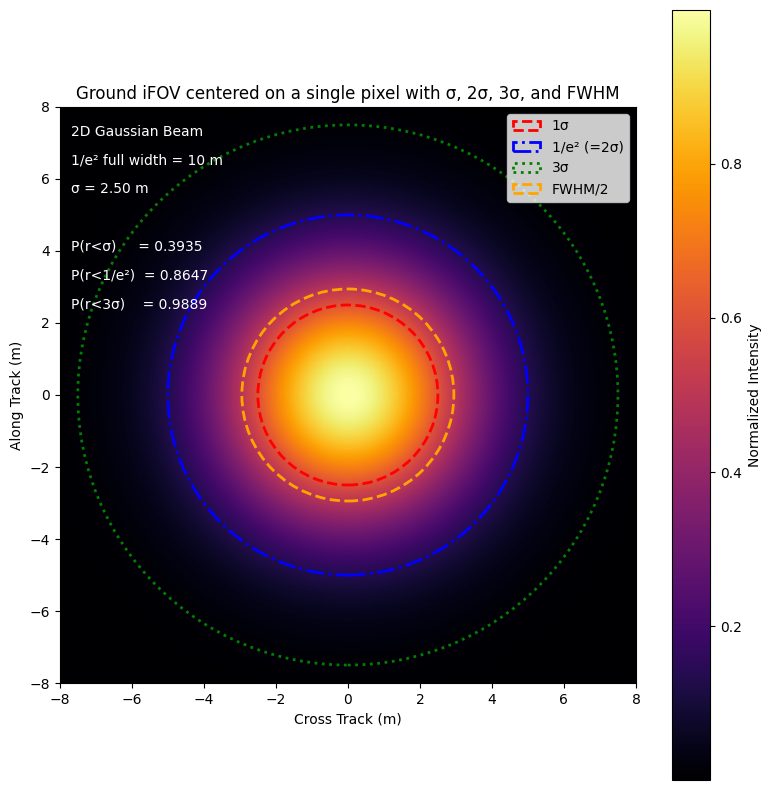

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
spot_1e2 = 10.0          # 1/e^2 full width [m]
sigma = spot_1e2 / 4     # Gaussian sigma [m]

extent = 8               # to capture iFOV of ground onto a pixel [m]
n = 500

# Grid
x = np.linspace(-extent, extent, n)
y = np.linspace(-extent, extent, n)
X, Y = np.meshgrid(x, y)
R2 = X**2 + Y**2

# 2D Gaussian (normalized peak = 1)
Z = np.exp(-R2 / (2 * sigma**2))

# Radii
r_1 = sigma
r_2 = 2 * sigma          # = 1/e^2 radius
r_3 = 3 * sigma
r_fwhm = sigma * np.sqrt(2 * np.log(2))

# Encircled power
def encircled(R):
    return 1 - np.exp(-R**2 / (2 * sigma**2))

# Plot
plt.figure(figsize=(8, 8))
im = plt.imshow(Z, extent=[-extent, extent, -extent, extent], origin="lower", cmap="inferno")

# Overlays
for r, c, ls, lbl in [
    (r_1, "red", "--", "1σ"),
    (r_2, "blue", "-.", "1/e² (=2σ)"),
    (r_3, "green", ":", "3σ"),
    (r_fwhm, "orange", "--", "FWHM/2"),
]:
    plt.gca().add_patch(
        plt.Circle((0, 0), r, fill=False, color=c, lw=2, ls=ls, label=lbl)
    )

# Text
plt.text(0.02, 0.95, "2D Gaussian Beam", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.90, "1/e² full width = 10 m", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.85, f"σ = {sigma:.2f} m", transform=plt.gca().transAxes, color="white")

plt.text(0.02, 0.75, f"P(r<σ)     = {encircled(r_1):.4f}", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.70, f"P(r<1/e²)  = {encircled(r_2):.4f}", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.65, f"P(r<3σ)    = {encircled(r_3):.4f}", transform=plt.gca().transAxes, color="white")

plt.xlabel("Cross Track (m)")
plt.ylabel("Along Track (m)")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.colorbar(im, label="Normalized Intensity")
plt.title("Ground iFOV centered on a single pixel with σ, 2σ, 3σ, and FWHM")
plt.tight_layout()
plt.show()


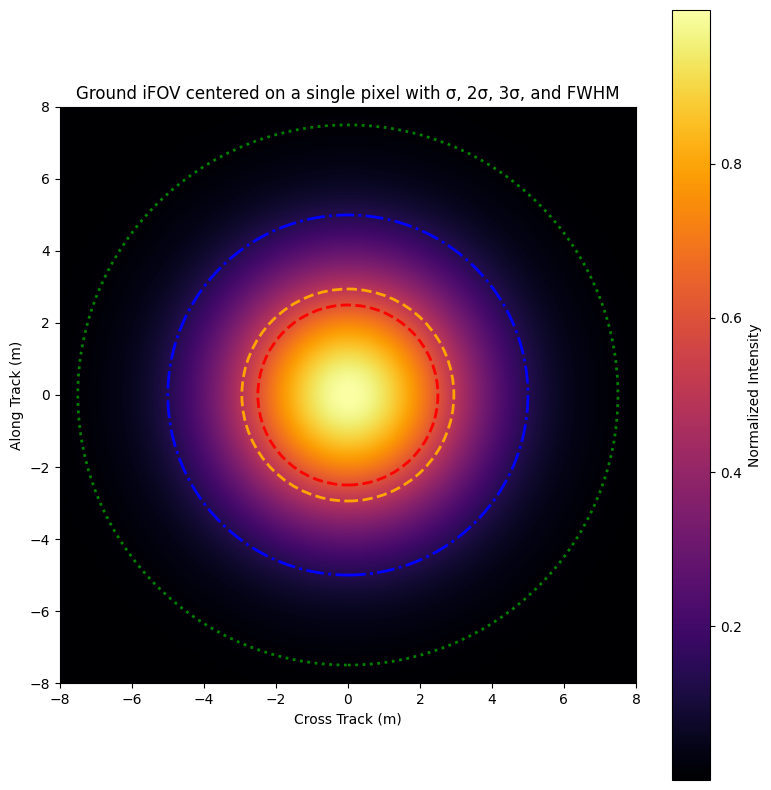

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
spot_1e2 = 10.0          # 1/e^2 full width [m]
sigma = spot_1e2 / 4     # Gaussian sigma [m]

extent = 8               # to capture iFOV of ground onto a pixel [m]
n = 600

# Grid
x = np.linspace(-extent, extent, n)
y = np.linspace(-extent, extent, n)
X, Y = np.meshgrid(x, y)
R2 = X**2 + Y**2

# 2D Gaussian (normalized peak = 1)
Z = np.exp(-R2 / (2 * sigma**2))

# Radii
r_1 = sigma
r_2 = 2 * sigma          # = 1/e^2 radius
r_3 = 3 * sigma
r_fwhm = sigma * np.sqrt(2 * np.log(2))

# Encircled power
def encircled(R):
    return 1 - np.exp(-R**2 / (2 * sigma**2))

# Plot
plt.figure(figsize=(8, 8))
im = plt.imshow(Z, extent=[-extent, extent, -extent, extent], origin="lower", cmap="inferno")

# Overlays
for r, c, ls, lbl in [
    (r_1, "red", "--", "1σ"),
    (r_2, "blue", "-.", "1/e² (=2σ)"),
    (r_3, "green", ":", "3σ"),
    (r_fwhm, "orange", "--", "FWHM/2"),
]:
    plt.gca().add_patch(
        plt.Circle((0, 0), r, fill=False, color=c, lw=2, ls=ls, label=lbl)
    )
# Plot
plt.xlabel("Cross Track (m)")
plt.ylabel("Along Track (m)")
plt.gca().set_aspect("equal")
#plt.legend(loc="upper right")
plt.title("Ground iFOV centered on a single pixel with σ, 2σ, 3σ, and FWHM")
plt.colorbar(im, label="Normalized Intensity")
plt.tight_layout()
plt.show()

In [93]:
import numpy as np
import pandas as pd

# Gaussian beam parameters
width_1e2 = 10.0  # 1/e² full width [m]
sigma = width_1e2 / 4

# Radii
r_1sigma = sigma
r_2sigma = 2 * sigma          # = 1/e² radius
r_3sigma = 3 * sigma
r_fwhm = sigma * np.sqrt(2 * np.log(2))

# Full widths
w_1sigma = 2 * r_1sigma
w_2sigma = 2 * r_2sigma
w_3sigma = 2 * r_3sigma
w_fwhm = 2 * r_fwhm

# Encircled power (2D Gaussian)
def encircled_power(R, sigma):
    return 1 - np.exp(-R**2 / (2 * sigma**2))

p_1sigma = encircled_power(r_1sigma, sigma)
p_2sigma = encircled_power(r_2sigma, sigma)
p_3sigma = encircled_power(r_3sigma, sigma)


# DataFrame
data = {
    "Parameter": [
        "Sigma (σ)",
        "1/e² full width",
        "1σ radius",
        "2σ radius (1/e²)",
        "3σ radius",
        "FWHM/2 radius",
        "1σ full width",
        "2σ full width (1/e²)",
        "3σ full width",
        "FWHM full width",
        "Encircled power r<σ",
        "Encircled power r<1/e²",
        "Encircled power r<3σ",
    ],
    "Value": [
        sigma,
        width_1e2,
        r_1sigma,
        r_2sigma,
        r_3sigma,
        r_fwhm,
        w_1sigma,
        w_2sigma,
        w_3sigma,
        w_fwhm,
        p_1sigma,
        p_2sigma,
        p_3sigma,
    ],
    "Units": [
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "-",
        "-",
        "-",
    ],
}

df = pd.DataFrame(data)

# table
def color_metric(val):
    if "power" in val:
        return "background-color: lightgreen; font-weight: bold"
    elif "radius" in val or "width" in val:
        return "background-color: lightblue"
    elif "Sigma" in val:
        return "background-color: lightyellow; font-weight: bold"
    else:
        return ""

styled = (
    df.style
    .format({"Value": "{:.3f}"})
    .applymap(color_metric, subset=["Parameter"])
    .set_caption("2D Gaussian Beam (1/e² = 10 m)")
    .set_table_styles([{"selector": "caption", "props": [("color", "darkred"),
                                                         ("font-size", "16px"),
                                                         ("font-weight", "bold")]}])
)

# Display 
styled


,Parameter,Value,Units
0,Sigma (σ),2.500,m
1,1/e² full width,10.000,m
2,1σ radius,2.500,m
3,2σ radius (1/e²),5.000,m
4,3σ radius,7.500,m
5,FWHM/2 radius,2.944,m
6,1σ full width,5.000,m
7,2σ full width (1/e²),10.000,m
8,3σ full width,15.000,m
9,FWHM full width,5.887,m


### Conclusion: The dimensionality of the space changes the distribution of the distance from the mean

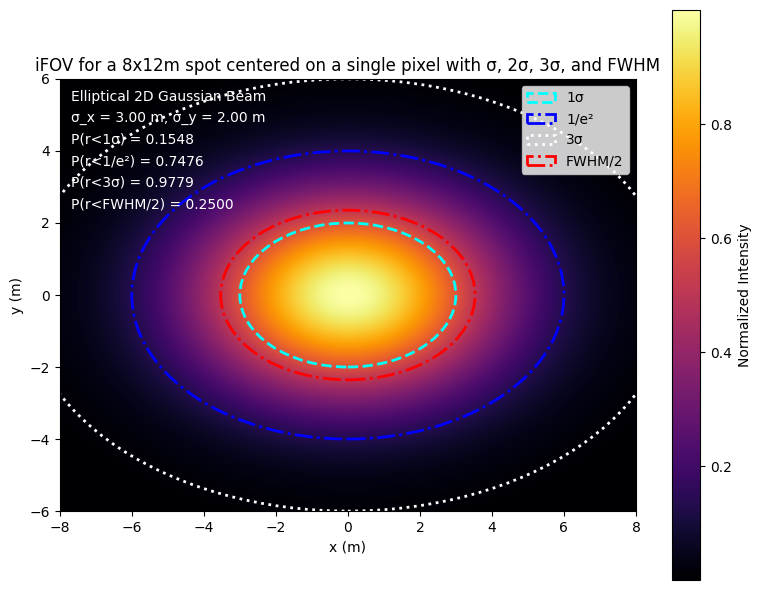

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Elliptical beam 
width_1e2_x = 12.0  # meters
width_1e2_y = 8.0   # meters

sigma_x = width_1e2_x / 4
sigma_y = width_1e2_y / 4

extent_x = 8
extent_y = 6
n = 600

# Grid
x = np.linspace(-extent_x, extent_x, n)
y = np.linspace(-extent_y, extent_y, n)
X, Y = np.meshgrid(x, y)

# 2D elliptical Gaussian (normalized peak = 1)
Z = np.exp(- (X**2 / (2*sigma_x**2) + Y**2 / (2*sigma_y**2)))

# Radii
r_1x, r_1y = sigma_x, sigma_y
r_2x, r_2y = 2*sigma_x, 2*sigma_y   # 1/e²
r_3x, r_3y = 3*sigma_x, 3*sigma_y
r_fwhm_x, r_fwhm_y = sigma_x*np.sqrt(2*np.log(2)), sigma_y*np.sqrt(2*np.log(2))

# Encircled power
def encircled_power_ellipse(Rx, Ry, sigma_x, sigma_y):
    return (1 - np.exp(-Rx**2/(2*sigma_x**2))) * (1 - np.exp(-Ry**2/(2*sigma_y**2)))

p_1 = encircled_power_ellipse(r_1x, r_1y, sigma_x, sigma_y)
p_2 = encircled_power_ellipse(r_2x, r_2y, sigma_x, sigma_y)
p_3 = encircled_power_ellipse(r_3x, r_3y, sigma_x, sigma_y)
p_fwhm = encircled_power_ellipse(r_fwhm_x, r_fwhm_y, sigma_x, sigma_y)

# Plot
plt.figure(figsize=(8,6))
im = plt.imshow(Z, extent=[-extent_x, extent_x, -extent_y, extent_y],
                origin='lower', cmap='inferno')

# Overlay ellipses
for (rx, ry, c, ls, lbl) in [
    (r_1x, r_1y, "cyan", "--", "1σ"),
    (r_2x, r_2y, "blue", "-.", "1/e²"),
    (r_3x, r_3y, "white", ":", "3σ"),
    (r_fwhm_x, r_fwhm_y, "red", "-.", "FWHM/2"),
]:
    ellipse = plt.matplotlib.patches.Ellipse((0,0), 2*rx, 2*ry, fill=False,
                                             color=c, ls=ls, lw=2, label=lbl)
    plt.gca().add_patch(ellipse)

# Text annotations
plt.text(0.02, 0.95, "Elliptical 2D Gaussian Beam", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.90, f"σ_x = {sigma_x:.2f} m, σ_y = {sigma_y:.2f} m", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.85, f"P(r<1σ) = {p_1:.4f}", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.80, f"P(r<1/e²) = {p_2:.4f}", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.75, f"P(r<3σ) = {p_3:.4f}", transform=plt.gca().transAxes, color="white")
plt.text(0.02, 0.70, f"P(r<FWHM/2) = {p_fwhm:.4f}", transform=plt.gca().transAxes, color="white")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.colorbar(im, label="Normalized Intensity")
plt.title("iFOV for a 8x12m spot centered on a single pixel with σ, 2σ, 3σ, and FWHM")
plt.tight_layout()
plt.show()
